# Quickstart

The following is a quickstart guide to using the DetectionPowerCalculator class.
This is a python package and is expected to be installed and imported as a module.
There is no command line interface.

## Installation

``` pip install komanawa-gw-detect-power ```

## Simple use case

The simplest base case is to use the DetectionPowerSlope class to estimate the probability of detecting a decreasing slope in a user provided time series of future values (e.g., contaminant concentrations).

Given a set of user values for the true concentration time series and the measurement error:

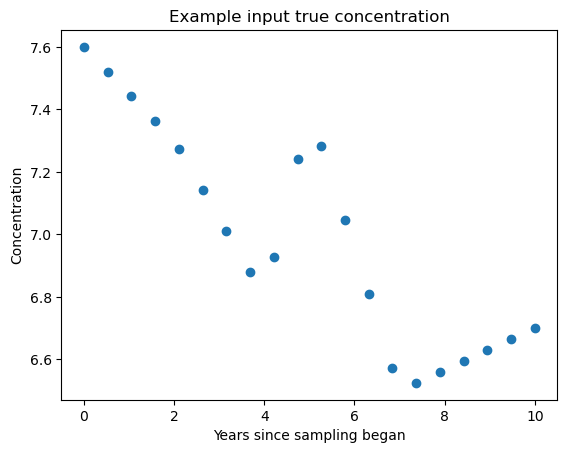

In [14]:
import numpy as np
import matplotlib.pyplot as plt
# standard deviation of the measurement error
noise = 0.5

# true concentration time series (10 years of quarterly sampling)
nyears = 10
nsamples_per_year = 2
sample_years = np.linspace(0, nyears, nyears*nsamples_per_year)

# building a concentration pathway -- typically this would be from another model

inflection_times = [0, 2, 4, 5, 7, 10]
inflection_concentrations = [7.6, 7.3, 6.8, 7.4, 6.5, 6.7]

true_conc = np.interp(sample_years, inflection_times, inflection_concentrations)
fig, ax = plt.subplots()
ax.scatter(sample_years, true_conc)
ax.set_title('Example input true concentration')
ax.set_xlabel('Years since sampling began')
ax.set_ylabel('Concentration')
plt.show()

We can estimate the probability of detecting a decreasing slope with a Mann-Kendall test after 10 years of sampling with 2 samples per year and a measurement error of 0.5 with the following code:

In [15]:
from komanawa.gw_detect_power import DetectionPowerSlope

detector = DetectionPowerSlope(significance_mode='mann-kendall')
power = detector.power_calc(
    idv='example',
    error=noise,
    true_conc_ts=true_conc,
)

print(f'Probability of detecting a decreasing slope with biannual sampling: {power["power"]:.2f}%')

Probability of detecting a decreasing slope with biannual sampling: 63.40%


If we increase the sampling frequency to 4 samples per year, we can see an increase in the probability of detecting a decreasing slope:

In [16]:
quarterly_samples = np.linspace(0, nyears, nyears*4)
true_conc_quarterly = np.interp(quarterly_samples, inflection_times, inflection_concentrations)

quarterly_power = detector.power_calc(
    idv='example',
    error=noise,
    true_conc_ts=true_conc_quarterly,
)
print(f'Probability of detecting a decreasing slope with quarterly sampling: {quarterly_power["power"]:.2f}%')

Probability of detecting a decreasing slope with quarterly sampling: 92.20%


There are other options for statistical tests, accounting for lag.
These are documented in the other worked examples and in the API documentation.